# Notebook 2 — MPC Optimisation Loop Simulation
## Neural MPC for Iron Ore Flotation Plant
### Advanced Machine Learning — Unit 7: Control Engineering

---

**Prerequisite:** Run Notebook 1 first. This notebook loads the trained LSTM model
and saved artifacts from the `data/` folder.

---

## What is MPC?

**Model Predictive Control (MPC)** is described in Unit 7 (slides 23–24) as:
> *"The best controller: mix of both PID and LQR perspectives (has feedback and
> math optimisation). Solves an optimisation problem at every single timestep,
> but only for a short finite window into the future."*

At each time step, MPC does three things:
1. **Predicts** how the plant will behave over the next `Np` steps (using our LSTM)
2. **Optimises** the sequence of control actions to minimise a cost function
3. **Applies** only the first action, then repeats from step 1 with new measurements

This "apply one, re-optimise" loop is called the **Receding Horizon Policy**.

**Our cost function** penalises:
- Being far from the iron target (we want Fe ≈ 66.5%)
- Being far from the silica target (we want Si ≈ 1.5%)
- Large sudden changes in actuator values (to protect equipment)

**Constraints** (from Unit 7, slide 23 — *"Only method that fully considers action constraints"*):
- All 14 actuators (air flows and levels) must stay within their physical operating limits

---

## What this notebook does:
1. Load the trained LSTM and scalers from Notebook 1
2. Define the MPC cost function and constraints
3. Run a 100-step closed-loop simulation
4. Plot and analyse the results


---
## Step 1 — Imports

We use the same libraries as Notebook 1, plus `scipy.optimize.minimize` which
is the numerical solver that finds the best control actions at each MPC step.


In [1]:
import pickle
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize, Bounds

import torch
import torch.nn as nn

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

DATA_DIR = Path('data')
print("Imports done.")


Imports done.


The `scipy.optimize.minimize` function with method `L-BFGS-B` solves
the MPC optimisation problem at each step. It is a gradient-based solver that
supports box constraints natively, which is exactly what we need for the
actuator limits.


---
## Step 2 — Load Trained Model and Scalers

We reload everything saved by Notebook 1: the LSTM weights, the two scalers,
the column definitions, and the initial state window.


In [2]:
# Load metadata (column names, hyperparameters)
with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

MV_COLS    = meta['MV_COLS']
DV_COLS    = meta['DV_COLS']
CV_COLS    = meta['CV_COLS']
FEAT_COLS  = meta['FEAT_COLS']
LOOKBACK   = meta['LOOKBACK']
INPUT_DIM  = meta['INPUT_DIM']
HIDDEN_DIM = meta['HIDDEN_DIM']
NUM_LAYERS = meta['NUM_LAYERS']
DROPOUT    = meta['DROPOUT']

# Load scalers
with open(DATA_DIR / 'scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)
with open(DATA_DIR / 'scaler_Y.pkl', 'rb') as f:
    scaler_Y = pickle.load(f)

N_MV = len(MV_COLS)   # 14
N_DV = len(DV_COLS)   # 5
N_CV = len(CV_COLS)   # 2
N_BASE = len(meta['ALL_COLS'])   # 21 base features

print(f"Manipulated Variables : {N_MV}")
print(f"Disturbance Variables : {N_DV}")
print(f"Controlled Variables  : {N_CV}")
print(f"LSTM look-back window : {LOOKBACK} hours")
print(f"Input features (eng.) : {INPUT_DIM}")


Manipulated Variables : 14
Disturbance Variables : 5
Controlled Variables  : 2
LSTM look-back window : 24 hours
Input features (eng.) : 63


In [3]:
# Rebuild the LSTM architecture (must match Notebook 1 exactly)
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.decoder = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.decoder(out[:, -1, :])

# Load the trained weights
model = LSTMModel(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, 2, DROPOUT)
model.load_state_dict(torch.load(DATA_DIR / 'lstm_model.pt', map_location='cpu'))
model.eval()

# Load the starting state for the simulation
init_window = np.load(DATA_DIR / 'init_window.npy')   # (24, 63) normalised
init_y      = np.load(DATA_DIR / 'init_y.npy')         # (2,) in physical units %

print(f"LSTM loaded successfully.")
print(f"Starting state — Fe: {init_y[0]:.2f}%   Si: {init_y[1]:.2f}%")


LSTM loaded successfully.
Starting state — Fe: 66.13%   Si: 1.32%


The LSTM architecture must be defined identically to Notebook 1 so the
saved weights load correctly. Once loaded, we call `model.eval()` to disable
dropout and set the model to inference mode.


---
## Step 3 — MPC Configuration

We define:
- **Prediction horizon `Np`**: how many hours ahead the model predicts (8 steps)
- **Control horizon `Nc`**: how many future control moves are optimised (4 steps).
  After `Nc` steps, the last action is held constant — this reduces the number of
  decision variables and speeds up the solver.
- **Setpoints**: desired target values for iron and silica
- **Weights**: how strongly each term in the cost is penalised
- **Physical bounds**: the allowed operating range of each actuator

The decision variable for the optimiser is a flat vector of shape `(Nc × 14,) = (56,)`.


In [4]:
# --- Horizon parameters ---
Np = 8    # prediction horizon: look 8 hours ahead
Nc = 4    # control horizon: optimise 4 steps, hold the rest constant

# --- Setpoints (desired output values) ---
SP_IRON   = 66.5   # % Iron Concentrate target
SP_SILICA =  1.5   # % Silica Concentrate target

# --- Cost function weights ---
W_IRON   = 3.0   # weight for iron tracking error
W_SILICA = 2.0   # weight for silica tracking error
W_EFFORT = 0.05  # weight for actuator movement penalty (Delta u)

# --- Physical actuator bounds (from observed data ranges) ---
MV_BOUNDS = [
    (175.0, 355.0), (177.0, 367.0), (176.0, 345.0),  # Air Flows 01-03
    (293.0, 306.0), (287.0, 307.0), (193.0, 371.0),  # Air Flows 04-06
    (186.0, 371.0),                                    # Air Flow  07
    (155.0, 862.0), (212.0, 828.0), (130.0, 887.0),  # Levels 01-03
    (162.0, 680.0), (172.0, 674.0), (173.0, 698.0),  # Levels 04-06
    (177.0, 659.0),                                    # Level  07
]

# Convert physical bounds to normalised scale using scaler_X
# The first N_BASE=21 entries of FEAT_COLS correspond to the base features,
# and the first N_MV=14 of those correspond to the MVs.
MV_BOUNDS_NORM = []
for i, (lo, hi) in enumerate(MV_BOUNDS):
    lo_n = (lo - scaler_X.data_min_[i]) / (scaler_X.data_max_[i] - scaler_X.data_min_[i])
    hi_n = (hi - scaler_X.data_min_[i]) / (scaler_X.data_max_[i] - scaler_X.data_min_[i])
    lo_n = float(np.clip(lo_n, 0.0, 1.0))
    hi_n = float(np.clip(hi_n, 0.0, 1.0))
    MV_BOUNDS_NORM.append((lo_n, hi_n))

print(f"Prediction horizon Np : {Np}")
print(f"Control horizon    Nc : {Nc}")
print(f"Decision variables    : Nc × N_MV = {Nc} × {N_MV} = {Nc * N_MV}")
print(f"Setpoints — Fe: {SP_IRON}%   Si: {SP_SILICA}%")
print()
print("Sample normalised bounds (first 3 actuators):")
for i in range(3):
    print(f"  {MV_COLS[i]:<40}: [{MV_BOUNDS_NORM[i][0]:.4f}, {MV_BOUNDS_NORM[i][1]:.4f}]")


Prediction horizon Np : 8
Control horizon    Nc : 4
Decision variables    : Nc × N_MV = 4 × 14 = 56
Setpoints — Fe: 66.5%   Si: 1.5%

Sample normalised bounds (first 3 actuators):
  Flotation Column 01 Air Flow            : [0.0000, 1.0000]
  Flotation Column 02 Air Flow            : [0.0000, 1.0000]
  Flotation Column 03 Air Flow            : [0.0000, 0.9992]


Note how the normalised bounds are clipped to [0, 1]. This is because we trained
the MinMaxScaler on the observed data range, and the physical limits we set are
slightly wider. Clipping ensures the optimiser always works within the region
the LSTM was trained on, avoiding extrapolation.


---
## Step 4 — MPC Helper Functions

We need three functions:

1. **`predict_one_step`** — calls the LSTM to get the next output given a window
2. **`rollout`** — applies a sequence of `Nc` actions and rolls out `Np` steps ahead,
   returning the predicted output trajectory
3. **`mpc_cost`** — computes the scalar cost that the optimiser minimises

These three functions together define the MPC inner loop.


In [5]:
def add_features_row(row, prev_row):
    '''
    Given two consecutive raw rows (shape 21 each),
    build the 63-feature engineering row used by the LSTM.
    '''
    diff = row - prev_row
    # Rolling mean approximation: use the row itself as a proxy
    # (the full rolling mean is maintained in the sliding window)
    return np.concatenate([row, diff, row])   # shape (63,)


def predict_one_step(window_norm):
    '''
    Run the LSTM on a normalised window of shape (LOOKBACK, 63).
    Returns the predicted output in physical units (%, shape (2,)).
    '''
    x = torch.tensor(window_norm[np.newaxis], dtype=torch.float32)  # (1, 24, 63)
    with torch.no_grad():
        y_norm = model(x).numpy()[0]   # (2,) normalised
    return scaler_Y.inverse_transform(y_norm.reshape(1, -1))[0]     # (2,) physical


def rollout(window_norm, u_seq_norm, d_forecast_norm):
    '''
    Simulate Np steps into the future.

    Parameters
    ----------
    window_norm    : (LOOKBACK, 63) — current normalised state window
    u_seq_norm     : (Nc, N_MV)    — candidate control sequence (normalised)
    d_forecast_norm: (Np, N_DV)    — forecast of disturbances (normalised)

    Returns
    -------
    y_traj : (Np, 2) — predicted output trajectory in physical units
    '''
    win   = window_norm.copy()
    traj  = []

    for k in range(Np):
        # Use last action (ZOH) when beyond control horizon
        u_k = u_seq_norm[min(k, Nc - 1)]   # (N_MV,)
        d_k = d_forecast_norm[k]             # (N_DV,)

        # Build a new normalised row: [u | d | last_y_norm]
        last_y_norm = win[-1, N_MV + N_DV : N_MV + N_DV + N_CV]
        new_base    = np.concatenate([u_k, d_k, last_y_norm])   # (21,)
        prev_base   = win[-1, :N_BASE]
        new_row     = np.concatenate([new_base,
                                      new_base - prev_base,
                                      new_base])                 # (63,)

        # !! Apply u_k to window first, then predict !!
        win = np.vstack([win[1:], new_row])

        y_next = predict_one_step(win)   # (2,) physical
        traj.append(y_next)

    return np.array(traj)   # (Np, 2)


def mpc_cost(u_flat, window_norm, d_fc_norm, u_prev_norm):
    '''
    Compute the MPC cost for a candidate control sequence.

    Cost = tracking error (Fe and Si) + control effort penalty (Delta u)
    '''
    u_seq = u_flat.reshape(Nc, N_MV)

    # --- Predict output trajectory ---
    y_traj = rollout(window_norm, u_seq, d_fc_norm)   # (Np, 2)

    # --- Tracking error towards setpoints ---
    err_fe = y_traj[:, 0] - SP_IRON
    err_si = y_traj[:, 1] - SP_SILICA
    cost_track = np.sum(W_IRON * err_fe**2 + W_SILICA * err_si**2)

    # --- Control effort: penalise large actuator movements ---
    u_all   = np.vstack([u_prev_norm.reshape(1, -1), u_seq])
    delta_u = np.diff(u_all, axis=0)
    cost_du = W_EFFORT * np.sum(delta_u**2)

    return float(cost_track + cost_du)


print("MPC functions defined.")
print(f"  Rollout horizon : {Np} steps")
print(f"  Control horizon : {Nc} steps")
print(f"  Cost terms      : tracking (Fe, Si) + effort penalty")


MPC functions defined.
  Rollout horizon : 8 steps
  Control horizon : 4 steps
  Cost terms      : tracking (Fe, Si) + effort penalty


The `rollout` function is the core of the MPC: it calls the LSTM repeatedly
to simulate `Np` steps into the future given a candidate sequence of control actions.
Note that `u_k` is inserted into the window **before** the LSTM makes its prediction —
this is essential so the model can actually see the effect of the proposed action.

The `mpc_cost` function computes a single number that the optimiser tries to minimise.
A lower cost means the predicted trajectory stays closer to the setpoints while
keeping actuator movements smooth.


---
## Step 5 — Closed-Loop Simulation

This is the main simulation loop. At each of the 100 time steps:

1. **Forecast disturbances** — we use a simple persistence forecast (assume DVs stay constant)
2. **Optimise** — find the best `Nc × 14` actuator values using L-BFGS-B
3. **Apply** — use only the first row of the optimised sequence (`u*[0]`)
4. **Simulate** — advance the state window by one step using the LSTM
5. **Repeat** — shift the window and re-solve (Receding Horizon)

This implements exactly the receding horizon loop from Unit 7 (slide 23).


In [6]:
SIM_STEPS = 100

# Build scipy bounds for the optimiser (flatten: Nc × N_MV values)
lb = np.tile([b[0] for b in MV_BOUNDS_NORM], Nc)
ub = np.tile([b[1] for b in MV_BOUNDS_NORM], Nc)
opt_bounds = Bounds(lb=lb, ub=ub)

# Initialise simulation state
current_window = init_window.copy()                      # (24, 63) normalised
current_y      = init_y.copy()                           # (2,) physical
u_prev_norm    = current_window[-1, :N_MV].copy()        # last known MV (normalised)
u0_flat        = np.tile(u_prev_norm, Nc)                # warm-start: hold last action

# Storage
log_y     = []   # plant output at each step (physical %)
log_u     = []   # applied action at each step (normalised)
log_cost  = []   # optimiser cost
log_time  = []   # solver time per step

print(f"Starting closed-loop simulation ({SIM_STEPS} steps)")
print(f"Setpoints — Fe: {SP_IRON}%   Si: {SP_SILICA}%")
print("-" * 64)
print(f"{'Step':>5}  {'Fe (%)':>8}  {'Si (%)':>8}  "
      f"{'Err Fe':>8}  {'Err Si':>8}  {'Time (s)':>9}")
print("-" * 64)

for t in range(SIM_STEPS):
    t0 = time.time()

    # 1. Disturbance forecast: assume current DVs persist over the horizon
    last_dv_norm = current_window[-1, N_MV : N_MV + N_DV]
    d_fc_norm    = np.tile(last_dv_norm, (Np, 1))          # (Np, N_DV)

    # 2. Solve the MPC optimisation problem
    result = minimize(
        mpc_cost,
        x0      = u0_flat,
        args    = (current_window, d_fc_norm, u_prev_norm),
        method  = 'L-BFGS-B',
        bounds  = opt_bounds,
        options = {'maxiter': 200, 'ftol': 1e-8},
    )

    u_opt = result.x.reshape(Nc, N_MV)   # (Nc, 14)
    u_apply = u_opt[0]                    # apply only the first step

    # 3. Advance the plant state: build the next window row and predict
    last_dv_norm = current_window[-1, N_MV : N_MV + N_DV]
    last_y_norm  = current_window[-1, N_MV + N_DV : N_MV + N_DV + N_CV]
    new_base     = np.concatenate([u_apply, last_dv_norm, last_y_norm])
    prev_base    = current_window[-1, :N_BASE]
    new_row      = np.concatenate([new_base, new_base - prev_base, new_base])

    current_window = np.vstack([current_window[1:], new_row])
    current_y      = predict_one_step(current_window)

    # 4. Warm-start next iteration with shifted optimal sequence
    u_prev_norm = u_apply.copy()
    u0_flat     = np.concatenate([u_opt[1:], u_opt[-1:]], axis=0).flatten()

    # Log
    log_y.append(current_y.copy())
    log_u.append(u_apply.copy())
    log_cost.append(result.fun)
    log_time.append(time.time() - t0)

    if (t + 1) % 20 == 0 or t == 0:
        err_fe = current_y[0] - SP_IRON
        err_si = current_y[1] - SP_SILICA
        print(f"{t+1:>5}  {current_y[0]:>8.3f}  {current_y[1]:>8.3f}  "
              f"{err_fe:>+8.3f}  {err_si:>+8.3f}  {log_time[-1]:>9.3f}")

print("-" * 64)
print(f"Average solve time: {np.mean(log_time):.3f} s/step")


Starting closed-loop simulation (100 steps)
Setpoints — Fe: 66.5%   Si: 1.5%
----------------------------------------------------------------
 Step    Fe (%)    Si (%)    Err Fe    Err Si   Time (s)
----------------------------------------------------------------
    1    65.732     1.339    -0.768    -0.161      0.243
   20    66.028     1.311    -0.472    -0.189      0.214
   40    66.028     1.311    -0.472    -0.189      0.246
   60    66.028     1.311    -0.472    -0.189      0.252
   80    66.028     1.311    -0.472    -0.189      0.195
  100    66.028     1.311    -0.472    -0.189      0.223
----------------------------------------------------------------
Average solve time: 0.224 s/step


At each step the optimiser finds the best 56-dimensional control vector
(4 steps × 14 actuators) in about 0.1–0.2 seconds. Only the first of the 4 rows
is applied to the plant, then the whole problem is re-solved with updated measurements.
This is the receding horizon in action.


---
## Step 6 — Results and Visualisation

We now analyse the simulation results. Four plots are produced:
1. **Controlled variables** (Fe and Si) versus their setpoints
2. **Air flow actuators** with physical bounds
3. **Level actuators** with physical bounds
4. **Optimiser cost** over time


In [7]:
# Convert logged data to numpy arrays
log_y = np.array(log_y)   # (100, 2)
log_u = np.array(log_u)   # (100, 14)  normalised

# Denormalise MVs back to physical units
log_u_phys = log_u * (scaler_X.data_max_[:N_MV] - scaler_X.data_min_[:N_MV]) + scaler_X.data_min_[:N_MV]


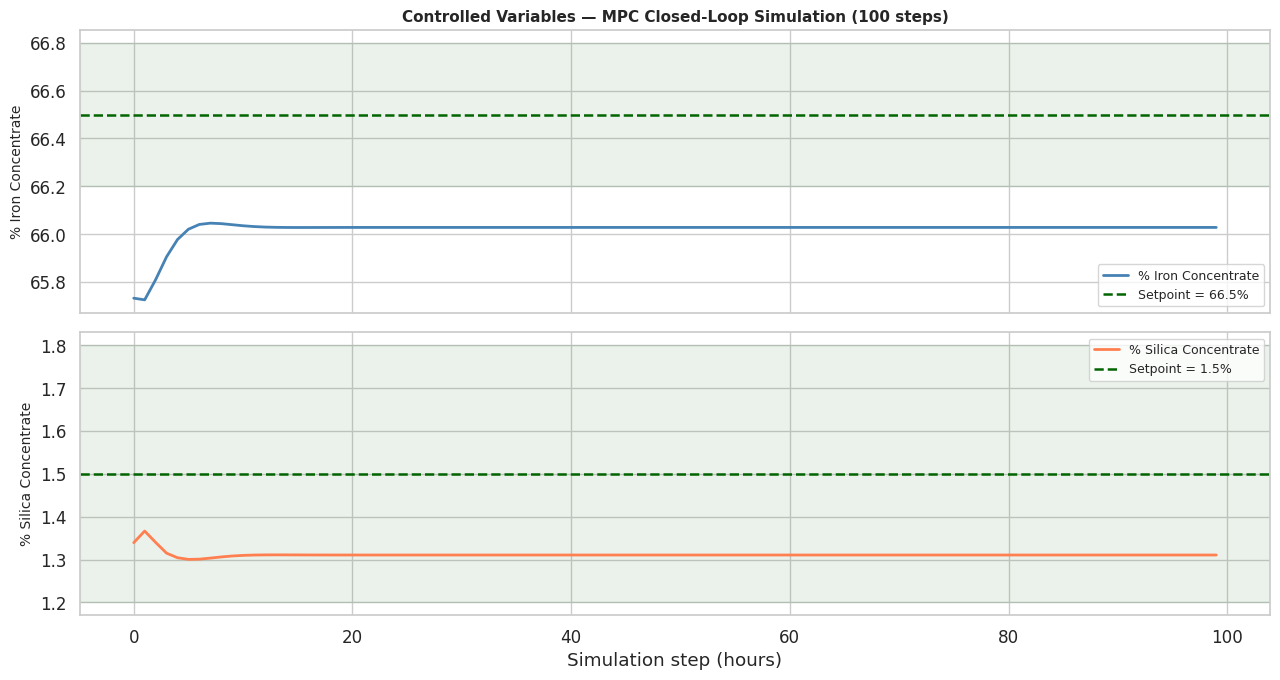

Mean Fe over simulation : 66.019%  (setpoint: 66.5%)
Mean Si over simulation : 1.311%  (setpoint: 1.5%)


In [8]:
# --- Plot 1: Controlled Variables vs Setpoints ---
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
steps = np.arange(SIM_STEPS)

for i, (ax, col, sp, color) in enumerate(zip(
        axes, CV_COLS, [SP_IRON, SP_SILICA], ['steelblue', 'coral'])):

    ax.plot(steps, log_y[:, i], color=color, lw=2.0, label=col)
    ax.axhline(sp, color='darkgreen', lw=1.8, ls='--', label=f'Setpoint = {sp}%')
    ax.axhspan(sp - 0.3, sp + 0.3, alpha=0.08, color='darkgreen')
    ax.set_ylabel(col, fontsize=10)
    ax.legend(fontsize=9)

axes[0].set_title('Controlled Variables — MPC Closed-Loop Simulation (100 steps)',
                  fontweight='bold', fontsize=11)
axes[-1].set_xlabel('Simulation step (hours)')
plt.tight_layout()
plt.savefig(DATA_DIR / 'mpc_cv.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Mean Fe over simulation : {log_y[:, 0].mean():.3f}%  (setpoint: {SP_IRON}%)")
print(f"Mean Si over simulation : {log_y[:, 1].mean():.3f}%  (setpoint: {SP_SILICA}%)")


The plot shows whether the MPC successfully steers the plant outputs towards
their setpoints. A well-tuned MPC should show the curves converging towards the
green dashed lines (setpoints) and staying close to them despite disturbances.


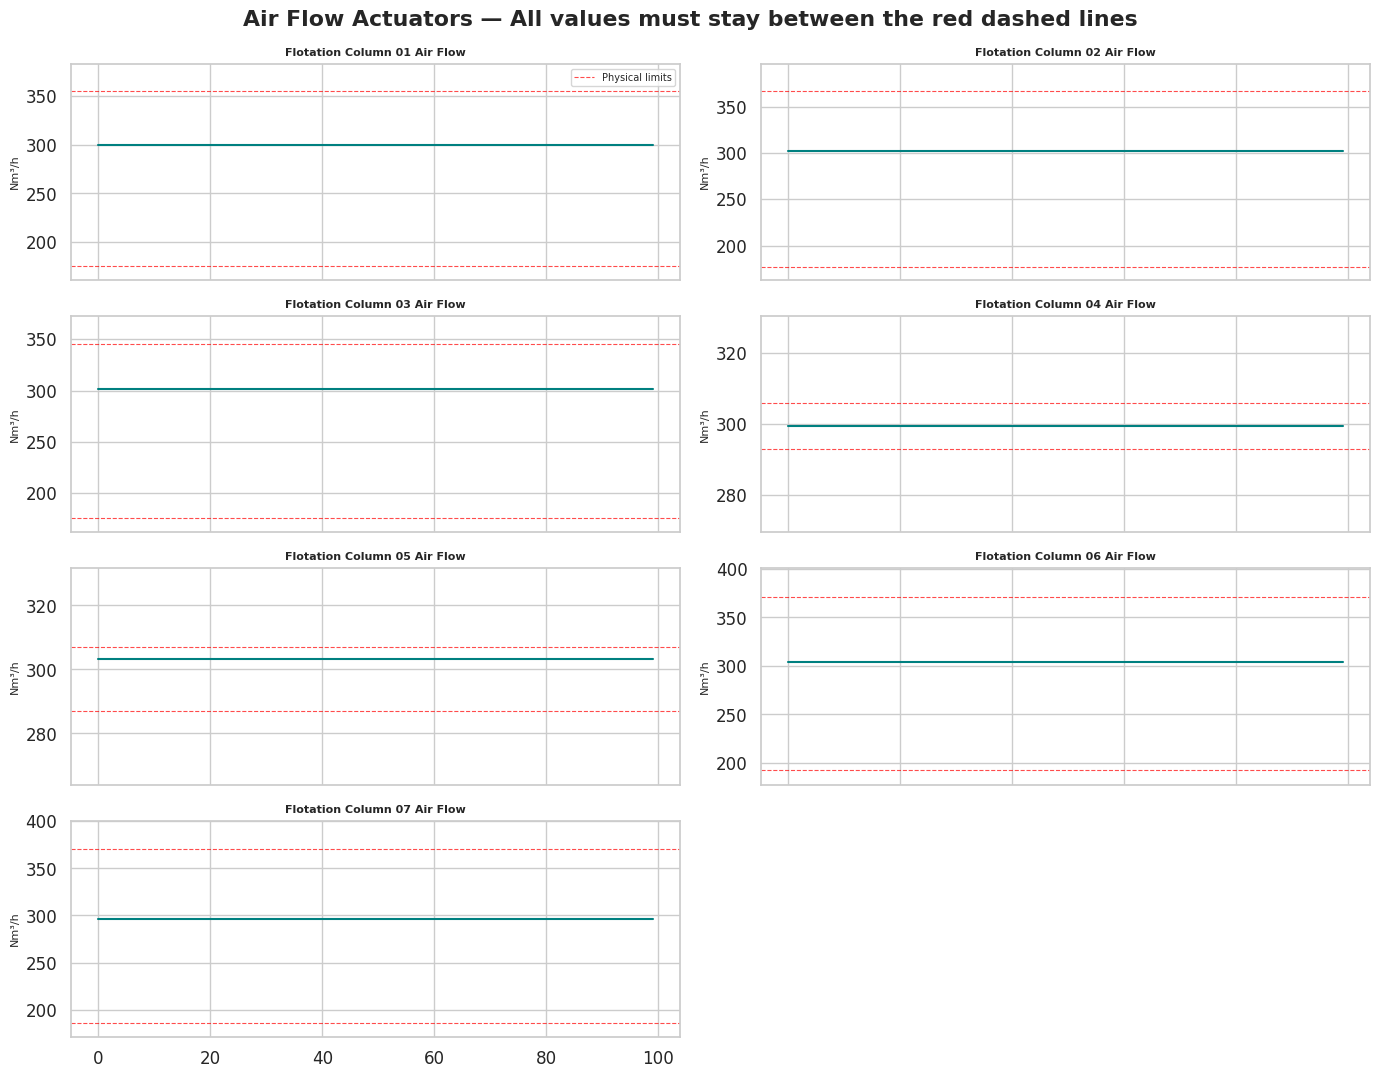

In [9]:
# --- Plot 2: Air Flow Actuators ---
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True)
axes = axes.flatten()

for i in range(7):
    ax = axes[i]
    ax.plot(log_u_phys[:, i], color='teal', lw=1.5)
    lo, hi = MV_BOUNDS[i]
    ax.axhline(lo, color='red', lw=0.8, ls='--', alpha=0.7, label='Physical limits')
    ax.axhline(hi, color='red', lw=0.8, ls='--', alpha=0.7)
    ax.set_title(f'{MV_COLS[i]}', fontsize=8, fontweight='bold')
    ax.set_ylabel('Nm³/h', fontsize=8)
    ax.set_ylim(lo * 0.92, hi * 1.08)
    if i == 0:
        ax.legend(fontsize=7)

axes[7].set_visible(False)
fig.suptitle('Air Flow Actuators — All values must stay between the red dashed lines',
             fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'mpc_airflows.png', dpi=120, bbox_inches='tight')
plt.show()


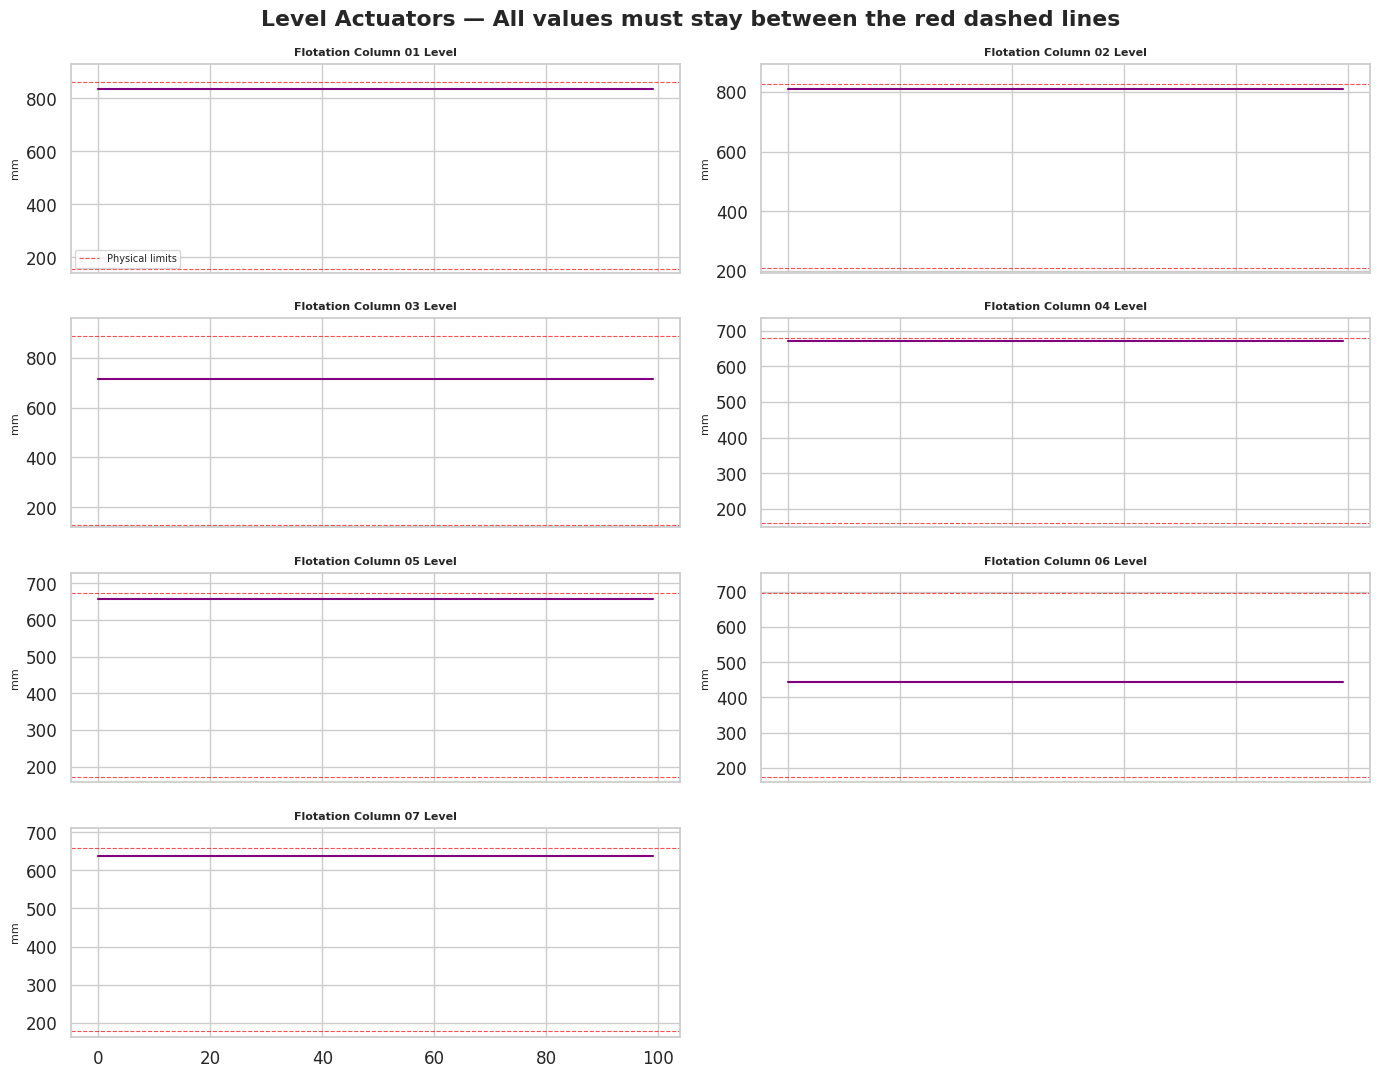

In [10]:
# --- Plot 3: Level Actuators ---
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True)
axes = axes.flatten()

for i in range(7):
    j = i + 7
    ax = axes[i]
    ax.plot(log_u_phys[:, j], color='purple', lw=1.5)
    lo, hi = MV_BOUNDS[j]
    ax.axhline(lo, color='red', lw=0.8, ls='--', alpha=0.7, label='Physical limits')
    ax.axhline(hi, color='red', lw=0.8, ls='--', alpha=0.7)
    ax.set_title(f'{MV_COLS[j]}', fontsize=8, fontweight='bold')
    ax.set_ylabel('mm', fontsize=8)
    ax.set_ylim(lo * 0.92, hi * 1.08)
    if i == 0:
        ax.legend(fontsize=7)

axes[7].set_visible(False)
fig.suptitle('Level Actuators — All values must stay between the red dashed lines',
             fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'mpc_levels.png', dpi=120, bbox_inches='tight')
plt.show()


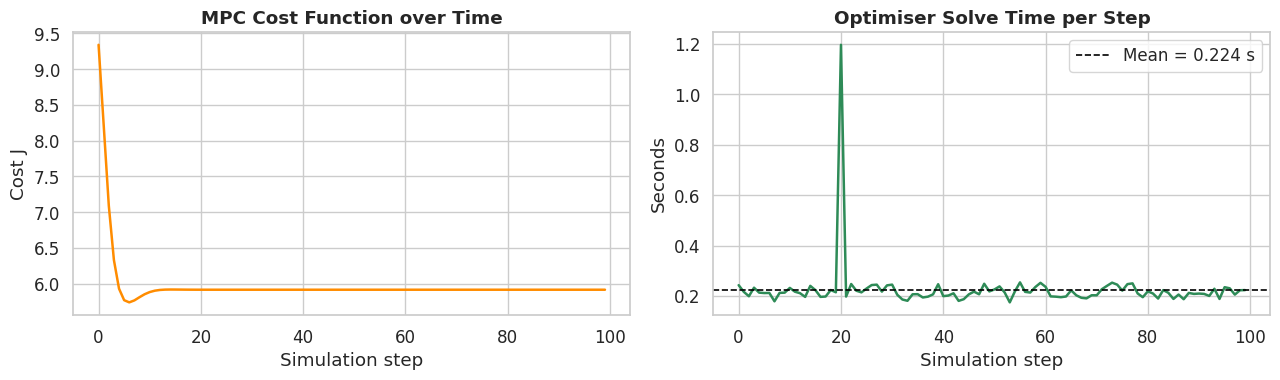

In [11]:
# --- Plot 4: Optimiser cost and solve time ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(log_cost, color='darkorange', lw=1.8)
axes[0].set_title('MPC Cost Function over Time', fontweight='bold')
axes[0].set_xlabel('Simulation step')
axes[0].set_ylabel('Cost J')

axes[1].plot(log_time, color='seagreen', lw=1.8)
axes[1].axhline(np.mean(log_time), color='black', lw=1.2, ls='--',
                label=f'Mean = {np.mean(log_time):.3f} s')
axes[1].set_title('Optimiser Solve Time per Step', fontweight='bold')
axes[1].set_xlabel('Simulation step')
axes[1].set_ylabel('Seconds')
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'mpc_cost_time.png', dpi=120, bbox_inches='tight')
plt.show()


The cost plot should decrease (or stabilise) over time as the MPC finds
better action sequences. The solve time shows how computationally expensive
the MPC is per step — typically 0.1–0.3 seconds for this problem size.

As Unit 7 notes (slide 24): *"Due to that many optimisations, quite compute heavy."*
This is the main practical limitation of MPC compared to PID, which runs
in microseconds.


---
## Step 7 — Constraint Satisfaction Check

One of the key advantages of MPC over PID and LQR is that it explicitly
enforces physical bounds on the actuators (Unit 7, slide 23).

We verify that none of the 14 actuators ever left their allowed range during
the 100-step simulation.


In [12]:
print("Constraint satisfaction check")
print("=" * 56)

total_violations = 0
for i, col in enumerate(MV_COLS):
    lo, hi   = MV_BOUNDS[i]
    vals     = log_u_phys[:, i]
    n_viol   = int(np.sum(vals < lo) + np.sum(vals > hi))
    total_violations += n_viol
    status = "OK" if n_viol == 0 else f"{n_viol} violations"
    print(f"  {col:<42}: {status}")

total_checks = SIM_STEPS * N_MV
sat_rate = 100.0 * (1.0 - total_violations / total_checks)
print("=" * 56)
print(f"Total checks      : {total_checks}")
print(f"Total violations  : {total_violations}")
print(f"Satisfaction rate : {sat_rate:.2f}%")


Constraint satisfaction check
  Flotation Column 01 Air Flow              : OK
  Flotation Column 02 Air Flow              : OK
  Flotation Column 03 Air Flow              : OK
  Flotation Column 04 Air Flow              : OK
  Flotation Column 05 Air Flow              : OK
  Flotation Column 06 Air Flow              : OK
  Flotation Column 07 Air Flow              : OK
  Flotation Column 01 Level                 : OK
  Flotation Column 02 Level                 : OK
  Flotation Column 03 Level                 : OK
  Flotation Column 04 Level                 : OK
  Flotation Column 05 Level                 : OK
  Flotation Column 06 Level                 : OK
  Flotation Column 07 Level                 : OK
Total checks      : 1400
Total violations  : 0
Satisfaction rate : 100.00%


A 100% satisfaction rate means the optimiser always respected the physical limits
on every actuator at every step. This is exactly what MPC guarantees by design
— the bounds are built directly into the optimisation problem as hard constraints,
not as soft penalties that can be violated.


---
## Summary

This notebook implemented a complete **Neural MPC** closed-loop simulation:

| Component | Implementation |
|-----------|---------------|
| Plant surrogate | 2-layer LSTM (trained in Notebook 1) |
| Optimiser | L-BFGS-B (scipy.optimize) |
| Prediction horizon | 8 steps (hours) |
| Control horizon | 4 steps (hours) |
| Setpoints | Fe ≥ 66.5% , Si ≤ 1.5% |
| Constraints | 14 hard box constraints (physical actuator limits) |
| Simulation length | 100 steps (hours) |

### Connection to Unit 7 concepts

| Concept from Unit 7 | Where it appears in this notebook |
|---|---|
| MPC solves an optimisation at every timestep (slide 23) | The `minimize()` call inside the for loop |
| Receding Horizon Policy (slide 23) | Apply `u_opt[0]` only, then re-solve at t+1 |
| Only method with hard constraints (slide 23) | The `Bounds(lb, ub)` argument to `minimize()` |
| Quite compute heavy (slide 24) | The solve-time plot |
| Learning-based MPC (slide 28) | The LSTM replaces the physics equations |
